# V2_2 · Lung — BEAM walkthrough

**Data**: `lung_cds.h5ad` is the bundled mouse lung-development CDS — the
authors of monocle2 already ran `reduce_dimension(DDRTree)` and `order_cells`,
so we use it directly to demonstrate **BEAM** without re-running TI.

**This notebook**:
1. Load the pre-built CDS and show the trajectory
2. Run BEAM at `branch_point = 1`
3. Branch heatmap of top BEAM genes
4. Per-branch pseudotime curves for `Ccnd2 / Sftpb / Pdpn`

In [1]:
import warnings
warnings.filterwarnings('ignore')

from monocle2py import (
    beam,
    estimate_dispersions,
    estimate_size_factors,
    load_lung_cds,
    order_cells,
    plot_cell_trajectory,
    plot_genes_branched_heatmap,
    plot_genes_branched_pseudotime,
    reduce_dimension,
)

In [2]:
lung = load_lung_cds()
print('lung_cds:', lung.shape)
lung.obs[['Time', 'State']].head()

lung_cds: (185, 218)


,Time,State
SRR1033854_0,E18.5,1
SRR1033855_0,E18.5,1
SRR1033856_0,E18.5,1
SRR1033859_0,E18.5,3
SRR1033860_0,E18.5,3


## 1. Display the pre-computed trajectory

The bundled CDS already carries a DDRTree state and per-cell pseudotime/State.
We re-run `estimate_size_factors`, `reduce_dimension` and `order_cells` so that
the Python pipeline is the source of truth for the rest of the notebook.

In [3]:
estimate_size_factors(lung)
reduce_dimension(
    lung, max_components=2, reduction_method='DDRTree',
    auto_param_selection=False, max_iter=20, verbose=False,
)
order_cells(lung)
print('States:', sorted(lung.obs['State'].astype(int).unique().tolist()))

States: [1, 2, 3]


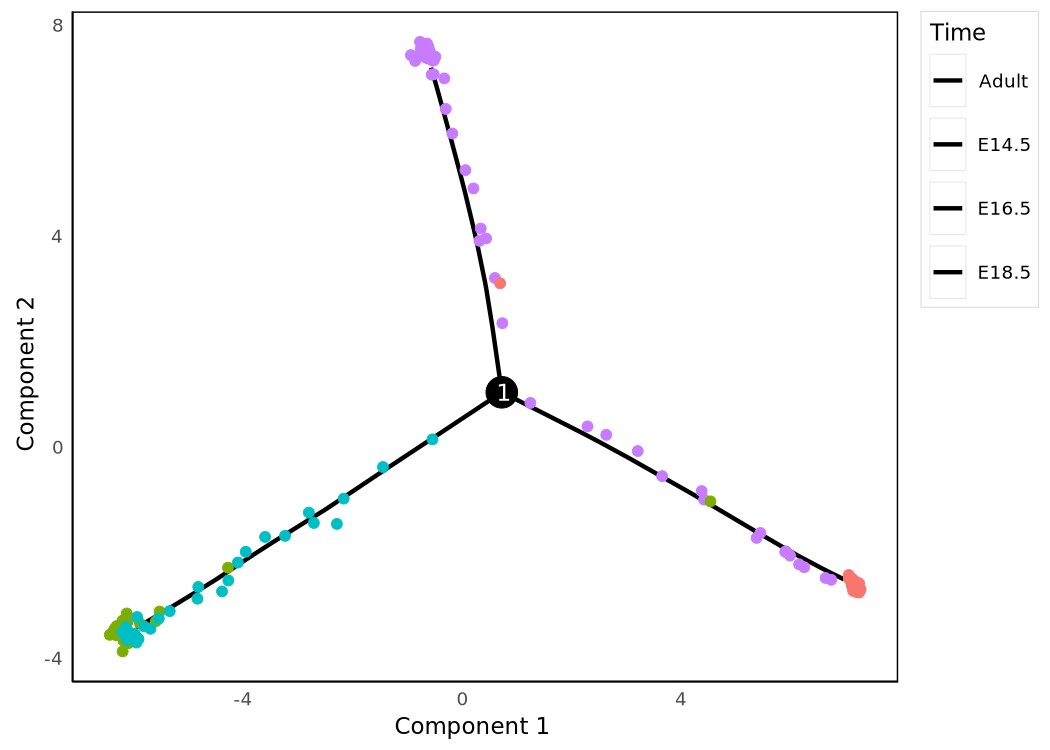

In [4]:
plot_cell_trajectory(lung, color_by='Time')

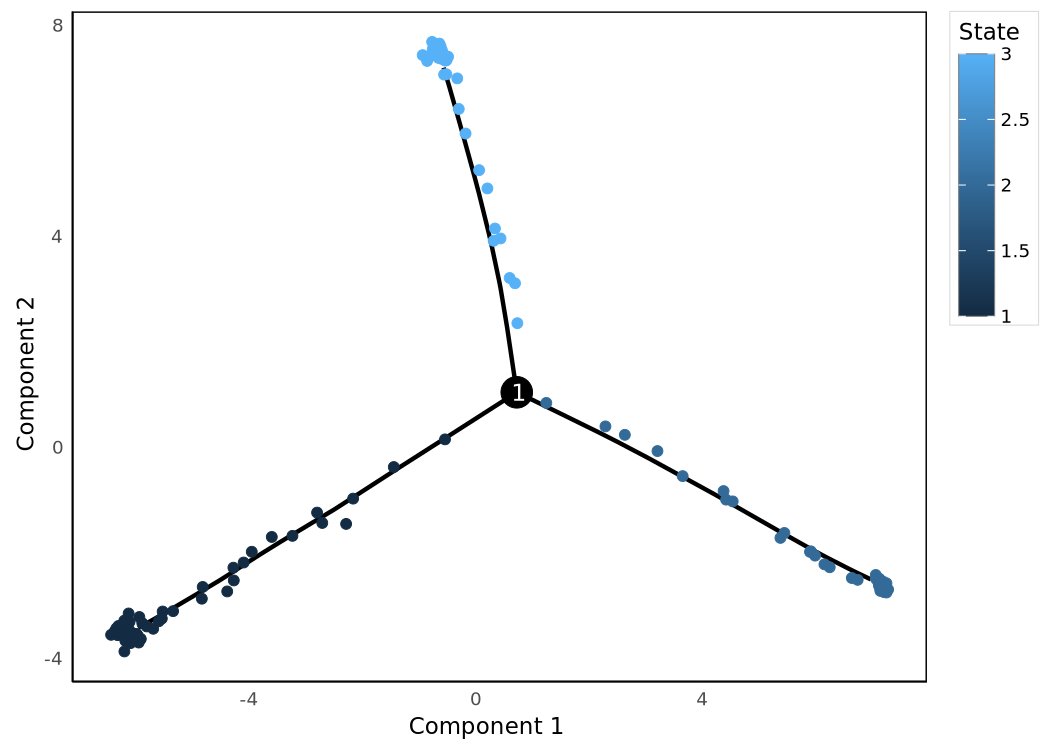

In [5]:
plot_cell_trajectory(lung, color_by='State', show_branch_points=True)

## 2. BEAM — branch-dependent gene test

For the two child branches at `branch_point = 1`, BEAM fits two smoothing
models per gene (branch-dependent vs. branch-independent) and runs a
likelihood-ratio test. Small qval ⇒ strong branch dependence.

In [6]:
estimate_dispersions(lung, min_cells_detected=1, remove_outliers=False)
beam_res = beam(lung, branch_point=1).sort_values('qval')
print('total genes tested:', len(beam_res),
      '| qval<1e-4:', int((beam_res['qval'] < 1e-4).sum()))
beam_res[['gene_short_name', 'pval', 'qval']].head(15)

/home/groups/xiaojie/nianping/Conda_Files/envs/scomics/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "
/home/groups/xiaojie/nianping/Conda_Files/envs/scomics/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


total genes tested: 218 | qval<1e-4: 88


,gene_short_name,pval,qval
gene_id,,,
ENSMUSG00000069516.7,Lyz2,5.758242e-35,1.226506e-32
ENSMUSG00000007655.10,Cav1,3.129696e-30,3.333126e-28
ENSMUSG00000001025.4,S100a6,6.342764e-29,4.503362e-27
ENSMUSG00000021789.8,Sftpa1,2.071233e-26,1.102932e-24
ENSMUSG00000029829.3,Tmem213,1.522811e-24,6.487176e-23
ENSMUSG00000021057.9,Akap5,5.750450e-24,2.041410e-22
ENSMUSG00000045954.6,Sdpr,1.763055e-22,5.364724e-21
ENSMUSG00000028883.11,Sema3a,8.166915e-22,2.174441e-20
ENSMUSG00000025150.4,Cbr2,1.830449e-21,4.332062e-20


## 3. Branch heatmap of top BEAM genes

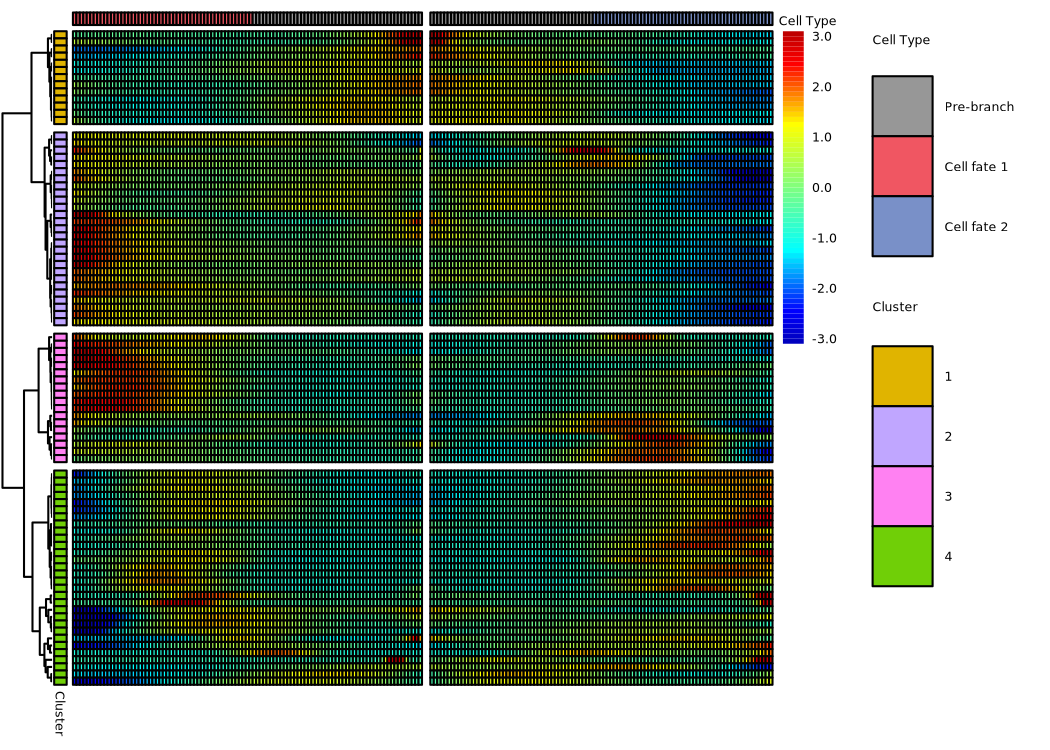

In [7]:
top_genes = beam_res[beam_res['qval'] < 1e-4].index.tolist()
plot_genes_branched_heatmap(
    lung[:, top_genes], branch_point=1,
    num_clusters=4, use_gene_short_name=True,
    show_rownames=False,
)

## 4. Single-gene branched pseudotime curves

`Ccnd2 / Sftpb / Pdpn` along the two branches — a proliferation marker, a
distal-lung epithelial marker, and a type-I alveolar marker.

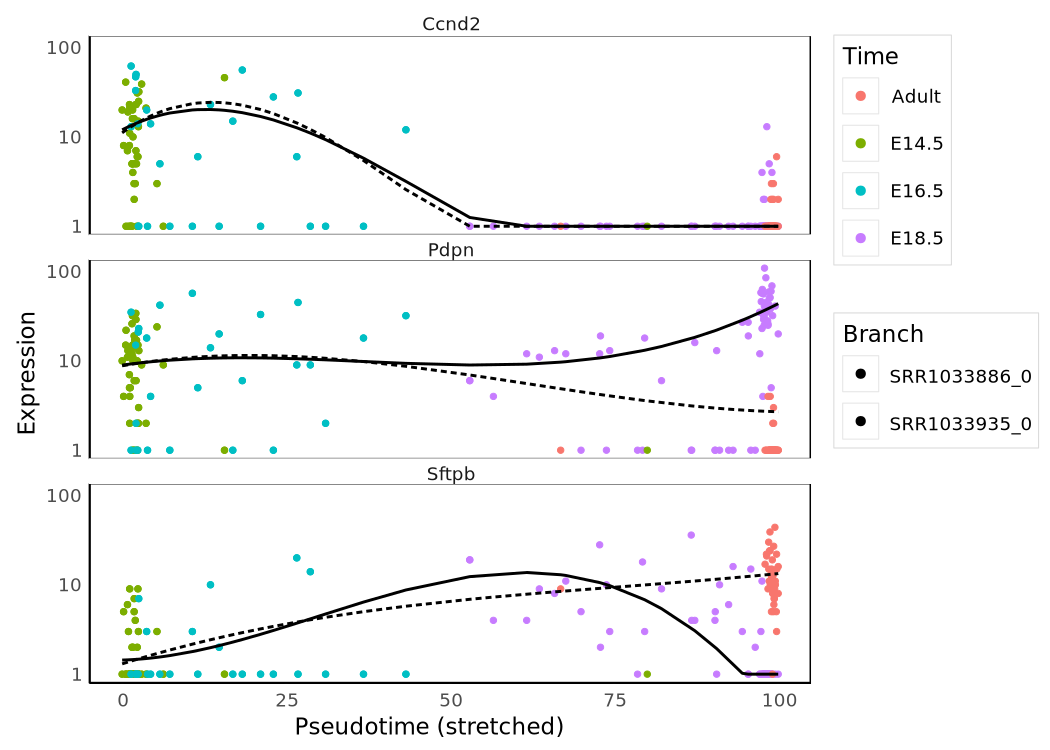

In [8]:
panel = ['Ccnd2', 'Sftpb', 'Pdpn']
lung_genes = lung.var_names[lung.var['gene_short_name'].isin(panel)].tolist()
plot_genes_branched_pseudotime(
    lung[:, lung_genes], branch_point=1, color_by='Time', ncol=1,
)